# 6. Regresión: Estimación de Cargos Mensuales

**Punto de partida:** el mismo dataset preprocesado por `3_FeatureEngineering.ipynb` (`../data/preprocessed_data.csv`) que ya se usó en los módulos de clasificación (4 y 5).

**Objetivo del notebook:** hasta ahora el proyecto abordó un problema de **clasificación** (predecir si un cliente abandona o no). Este módulo cambia el tipo de problema a uno de **regresión**: estimar un valor numérico continuo — `MonthlyCharges`, el cargo mensual del cliente — en lugar de una categoría.

Se reutiliza el dataset ya conocido, transformado y con el que los estudiantes ya tienen familiaridad, para enfocar el módulo en lo nuevo: **el tipo de problema, sus algoritmos y sus métricas de evaluación**, en lugar de volver a explicar la preparación de datos desde cero.

### ¿Por qué estimar el cargo mensual?
En un escenario de negocio real, este tipo de modelo podría usarse para: estimar el cargo esperado de un cliente nuevo antes de tener su primera factura, detectar clientes cuyo cargo real se aleja mucho del esperado según su perfil de servicios (posible error de facturación o de captura), o simular el impacto en ingresos de cambios en la combinación de servicios contratados.

In [1]:
# Plomería del entorno (no es parte del análisis): se fija la versión de
# scikit-learn. Los modelos serializados en ../models/*.pkl se guardaron con la
# 1.9.0, y joblib.load() advierte o falla al abrirlos con una versión distinta.
%pip install -q scikit-learn==1.9.0

import sklearn
print("scikit-learn:", sklearn.__version__)
if sklearn.__version__ != "1.9.0":
    print("Versión distinta a la esperada (1.9.0).")
    print("En Colab: menú Entorno de ejecución > Reiniciar sesión, y ejecuta de nuevo esta celda.")

Note: you may need to restart the kernel to use updated packages.
scikit-learn: 1.9.0


In [2]:
import joblib
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## cargar librerias de visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

### Librerías nuevas frente a los módulos de clasificación

Se reutilizan `pandas`, `seaborn`, `matplotlib` y `train_test_split` tal cual. Lo nuevo:

- **Modelos de regresión**: `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor` — los   equivalentes de regresión de los tres algoritmos ya usados en clasificación (Regresión Logística →   Regresión Lineal, Decision Tree**Classifier** → Decision Tree**Regressor**, y lo mismo para Random   Forest). La lógica de comparar varios algoritmos con el mismo pipeline se mantiene igual.
- **Métricas de regresión**: `r2_score`, `root_mean_squared_error`, `mean_absolute_error` — no aplican   aquí los conceptos de precision/recall/matriz de confusión, porque ya no hay clases discretas que   acertar o fallar, sino una distancia numérica entre el valor predicho y el valor real.

> Algunos imports (`roc_auc_score`, `roc_curve`, `classification_report`, `confusion_matrix`) quedan del copy-paste de los módulos anteriores y no se usan en este notebook — no generan error por estar sin usar, pero se pueden retirar si se busca un archivo de imports más limpio.

### Parámetros del experimento

- **`target`**: ahora es `"monthlycharges"` — antes era una variable predictora, aquí pasa a ser lo que   se quiere predecir.
- **`metric`**: `"r2"` (coeficiente de determinación), la métrica más habitual para comparar modelos de   regresión de forma normalizada (ver explicación más abajo).

> **Nota:** `num_feat` conserva `"monthlycharges"` en la lista, heredado de los notebooks de clasificación (donde era una variable numérica más). Aquí `monthlycharges` es el `target`, así que si en una futura iteración se agrega un paso de escalamiento reutilizando `num_feat`, hay que quitarlo de esa lista primero — de lo contrario se estaría escalando la variable objetivo como si fuera una predictora.

In [3]:
target = "monthlycharges"
num_feat = ["tenure", "monthlycharges"]

metric = "r2"

## Cargar datos

Se reutiliza directamente `preprocessed_data.csv`, el mismo archivo que consume `4_Modeling.ipynb`. Todas las columnas quedan disponibles como predictoras (`feat`) excepto `monthlycharges`, que ahora es el `target` — incluyendo `churn`, que en los módulos de clasificación era la variable a predecir y aquí pasa a ser una variable predictora más.

> **Punto de discusión metodológica:** usar `churn` para predecir `monthlycharges` es válido como ejercicio didáctico porque ambas columnas ya existen en el dataset histórico. Pero en un caso de uso real — estimar el cargo de un cliente *antes* de que ocurra el churn — `churn` no estaría disponible al momento de hacer la predicción, y usarla introduciría fuga de información (data leakage) hacia el pasado del cliente en vez de información disponible al momento de cotizar.

In [4]:
fName = "../data/preprocessed_data.csv"
data = pd.read_csv(fName, sep=",", na_values=[""," ","-","NA"])
data.set_index("customerID", inplace=True)
feat = [c for c in data if c!=target]
print(f"Datos cargados desde {fName} con shape={data.shape}")
data.head()

Datos cargados desde ../data/preprocessed_data.csv con shape=(7043, 25)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn
customerID,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,1,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,1,0,1,0,0,0,0,1,0,0
5575-GNVDE,0,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1,0,0,1,0,0,0,0,1,0
3668-QPYBK,0,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,1,0,1,0,0,0,0,0,1,1
7795-CFOCW,0,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1,0,0,1,0,1,0,0,0,0
9237-HQITU,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,0,1,1,0,0,0,0,1,0,1


Se separan las variables predictoras (`X`) y la variable objetivo (`y`), igual que en los módulos de clasificación.

In [5]:
X = data[feat].copy()
y = data[target].copy()
print(f"{X.shape=}, {y.shape=}")

X.shape=(7043, 24), y.shape=(7043,)


## Partición en entrenamiento y prueba

A diferencia de la clasificación, aquí **no se usa `stratify`**: ese parámetro solo tiene sentido cuando existen clases discretas a preservar en proporción; `monthlycharges` es una variable continua. En su lugar, se comparan las estadísticas descriptivas de `y_train` vs. `y_test` para verificar que ambos subconjuntos tengan una distribución similar del cargo mensual (medias, cuartiles y rangos parecidos), como chequeo informal de que la partición aleatoria no introdujo un desbalance relevante.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123)

print("Train:", X_train.shape, " - Test :", X_test.shape)
pd.DataFrame({"y_train": y_train.describe(), "y_test": y_test.describe()}).T

Train: (5634, 24)  - Test : (1409, 24)


,count,mean,std,min,25%,50%,75%,max
y_train,5634.0,64.665158,30.051248,18.25,35.5625,70.20,89.90,118.75
y_test,1409.0,65.147693,30.252321,18.70,35.4000,70.75,89.55,118.65


### Chequeo exploratorio: cargo mensual según Churn

Antes de modelar, se revisa si el cargo mensual difiere entre clientes que abandonaron y los que no. Esto es útil como contexto de negocio y también explica por qué `churn` puede tener poder predictivo sobre `monthlycharges` en este ejercicio.

In [7]:
print("Distribución por Churn")
data.groupby("churn")[target].describe()

Distribución por Churn


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


## Modelos de regresión

Se entrenan y comparan los tres algoritmos equivalentes a los usados en clasificación, para mantener el mismo enfoque de benchmarking:

| Modelo | Tipo | Equivalente en clasificación |
|---|---|---|
| `LinearRegression` | Lineal | Regresión Logística |
| `DecisionTreeRegressor` | Basado en árboles | Decision Tree Classifier |
| `RandomForestRegressor` | Ensamble de árboles | Random Forest Classifier |

A diferencia de la Regresión Logística (que predice una probabilidad entre 0 y 1 y luego una clase), la Regresión Lineal predice directamente el valor numérico esperado del cargo mensual.

In [8]:
models = {
        "LinearRegression": LinearRegression(),
        "DecisionTree": DecisionTreeRegressor(random_state=123),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=123)
    }

### Entrenamiento y métricas sobre `train`

Se calculan tres métricas estándar de regresión sobre los mismos datos de entrenamiento:

- **R² (coeficiente de determinación)**: qué proporción de la variabilidad de `monthlycharges` explica el   modelo. Va de `-∞` a `1`; `1` es ajuste perfecto, `0` equivale a predecir siempre el promedio.
- **MAE (Error Absoluto Medio)**: en promedio, cuántas unidades monetarias se equivoca el modelo, sin   importar si sobreestima o subestima. Fácil de interpretar en las unidades originales del target.
- **RMSE (Raíz del Error Cuadrático Medio)**: similar a MAE, pero penaliza más fuerte los errores grandes   (por elevarlos al cuadrado antes de promediar). Útil cuando los errores grandes son especialmente   costosos para el negocio.

Como en los módulos anteriores, esta evaluación sobre `train` sirve solo de referencia inicial — no debe usarse para elegir el mejor modelo.

In [9]:
train_metrics = []
train_predictions = dict()

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    train_metrics.append({
        "model": name,
        "r2": r2_score(y_train, y_pred),
        "mae": mean_absolute_error(y_train, y_pred),
        "rmse": root_mean_squared_error(y_train, y_pred),
    })
    train_predictions[name] = {"y_pred":y_pred}
train_metrics = pd.DataFrame(train_metrics).set_index("model")

train_metrics

,r2,mae,rmse
model,,,
LinearRegression,0.998851,0.777641,1.018697
DecisionTree,0.999954,0.047471,0.203991
RandomForest,0.999710,0.377075,0.512138


**¿Por qué el R² es tan alto (> 0.99) en los tres modelos?** Este resultado no es típico de un problema de regresión real. En este dataset, `MonthlyCharges` es prácticamente una función determinística de qué servicios contrató el cliente — compara más abajo los coeficientes de la Regresión Lineal: cada servicio suma un monto casi fijo al cargo mensual, como una lista de precios. Por eso los modelos no están descubriendo un patrón complejo con incertidumbre real: están reconstruyendo una fórmula de precios ya implícita en los datos.

En un problema de regresión real (por ejemplo, estimar el gasto en salud de un paciente o el ingreso de un hogar), un R² de 0.3 a 0.6 ya puede considerarse un resultado útil. No tomes este notebook como referencia de qué tan alto "debería" ser tu R² en otros proyectos.

### Validación cruzada

Se valida la estabilidad de cada modelo con `cv=5`, usando `neg_root_mean_squared_error` como métrica.

> **¿Por qué "neg" (negativo)?** Por convención, `scikit-learn` asume que un score **más alto es mejor** en todas sus herramientas de búsqueda y validación. RMSE es un error: mientras más bajo, mejor modelo — justo la lógica contraria. Para que ambas convenciones sean compatibles, `scikit-learn` niega el RMSE (`neg_root_mean_squared_error`), de modo que un score más alto (más cercano a 0) siga significando mejor desempeño. Al interpretar los resultados, basta con tomar el valor absoluto para volver a leerlo como el RMSE real.

In [10]:
cv_scores = dict()

for name, model in models.items():
    cv_scores[name] = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="neg_root_mean_squared_error",
        )
cv_scores = dict((k,{"mean": sco.mean(), "std": sco.std(), "folds": sco}) for k, sco in cv_scores.items())
cv_scores = pd.DataFrame.from_dict(cv_scores, orient="index")
cv_scores

,mean,std,folds
LinearRegression,-1.022207,0.020084,"[-1.0044454982517834, -1.0612021912301839, -1...."
DecisionTree,-1.739457,0.087932,"[-1.7170544835653287, -1.78842359840247, -1.84..."
RandomForest,-1.376571,0.050031,"[-1.3116665958714238, -1.4004830480676562, -1...."


### Evaluar desempeño con el conjunto de `test`

Se repiten las mismas tres métricas, ahora sobre datos que el modelo no vio durante el entrenamiento — la comparación que realmente importa para elegir el modelo final.

In [11]:
test_metrics = []
test_predictions = dict()

for name, model in models.items():
    y_pred = model.predict(X_test)
    test_metrics.append({
        "model": name,
        "r2": r2_score(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
    })
    test_predictions[name] = {"y_pred":y_pred}
test_metrics = pd.DataFrame(test_metrics).set_index("model")

test_metrics

,r2,mae,rmse
model,,,
LinearRegression,0.998796,0.798968,1.049233
DecisionTree,0.997313,1.154455,1.567561
RandomForest,0.998141,0.974787,1.303833


### Tabla comparativa: `train` vs. `test`

Se consolidan las métricas de ambos conjuntos en una sola tabla, agrupando cada métrica junto a su contraparte de train/test para facilitar detectar sobreajuste (una brecha grande entre `train` y `test` en cualquiera de las tres métricas).

In [12]:
resultados = pd.concat([train_metrics.add_suffix("_train"), test_metrics.add_suffix("_test")], axis=1)
resultados[[l for lst  in [[c+"_train",c+"_test"] for c in train_metrics] for l in lst]]

,r2_train,r2_test,mae_train,mae_test,rmse_train,rmse_test
model,,,,,,
LinearRegression,0.998851,0.998796,0.777641,0.798968,1.018697,1.049233
DecisionTree,0.999954,0.997313,0.047471,1.154455,0.203991,1.567561
RandomForest,0.999710,0.998141,0.377075,0.974787,0.512138,1.303833


## Selección del modelo final

Se elige el modelo con mejor desempeño según la métrica definida en `metric` (`r2`), evaluada sobre el conjunto de `test` — el mismo criterio de selección usado en `4_Modeling.ipynb`, adaptado a una métrica de regresión.

In [13]:
best_model_name = test_metrics.sort_values(metric, ascending=False).iloc[0].name
print(f"Mejor modelo según {metric.upper()}:", best_model_name)
test_metrics.loc[[best_model_name]]

Mejor modelo según R2: LinearRegression


,r2,mae,rmse
model,,,
LinearRegression,0.998796,0.798968,1.049233


## Análisis de residuos

El **residuo** de una predicción es la diferencia entre el valor real y el valor predicho (`y_test - y_pred`). Es un diagnóstico que no tiene equivalente directo en los modelos de clasificación ya vistos, y ayuda a detectar problemas que el R² por sí solo no muestra:

- **Dispersión aleatoria alrededor de 0** (sin forma reconocible): buena señal, el modelo no deja   patrones sistemáticos sin capturar.
- **Forma de embudo** (los residuos crecen o decrecen junto con el valor predicho): indica   heterocedasticidad — el modelo es menos preciso en ciertos rangos del cargo mensual.
- **Forma de curva**: sugiere una relación no lineal entre las variables predictoras y el target que un   modelo lineal no está capturando (los modelos basados en árboles son menos susceptibles a esto).

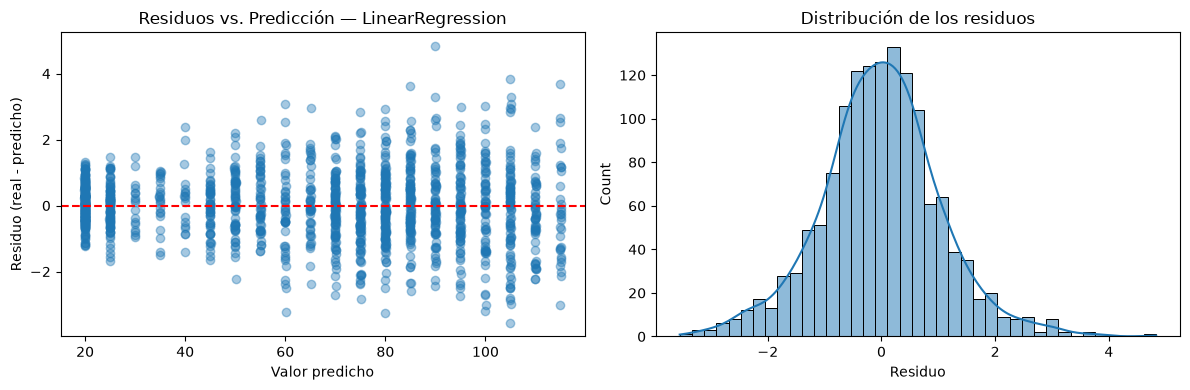

In [14]:
y_pred_final = test_predictions[best_model_name]["y_pred"]
residuos = y_test - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_final, residuos, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valor predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title(f"Residuos vs. Predicción — {best_model_name}")

sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title("Distribución de los residuos")
axes[1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()

Adicionalmente, el promedio de los residuos indica si el modelo tiende a sobreestimar o subestimar de forma sistemática: un promedio cercano a 0 es lo esperado; un valor claramente positivo o negativo sugiere un sesgo consistente en las predicciones.

In [15]:
print(f"Residuo promedio ({best_model_name}): {residuos.mean():,.4f}")
print(f"Desviación estándar de los residuos: {residuos.std():,.4f}")

Residuo promedio (LinearRegression): -0.0126
Desviación estándar de los residuos: 1.0495


## Interpretabilidad: importancia de variables y coeficientes

Independientemente de cuál haya resultado el mejor modelo, conviene revisar cómo explica cada tipo de algoritmo la relación entre las variables y el cargo mensual — la forma de interpretar un modelo depende de su naturaleza.

### Random Forest: importancia de variables

Igual que en `4_Modeling.ipynb`, el `RandomForestRegressor` permite obtener qué tan importante fue cada variable para reducir el error dentro de sus árboles.

In [16]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": models["RandomForest"].feature_importances_
}).sort_values("importance", ascending=False)

importance.head(15)

,feature,importance
15,internetservice_fiber optic,0.624131
14,internetservice_dsl,0.201143
12,streamingmovies,0.060096
11,streamingtv,0.039982
5,phoneservice,0.036229
8,onlinebackup,0.008431
7,onlinesecurity,0.007464
9,deviceprotection,0.007395
10,techsupport,0.006485
6,multiplelines,0.005438


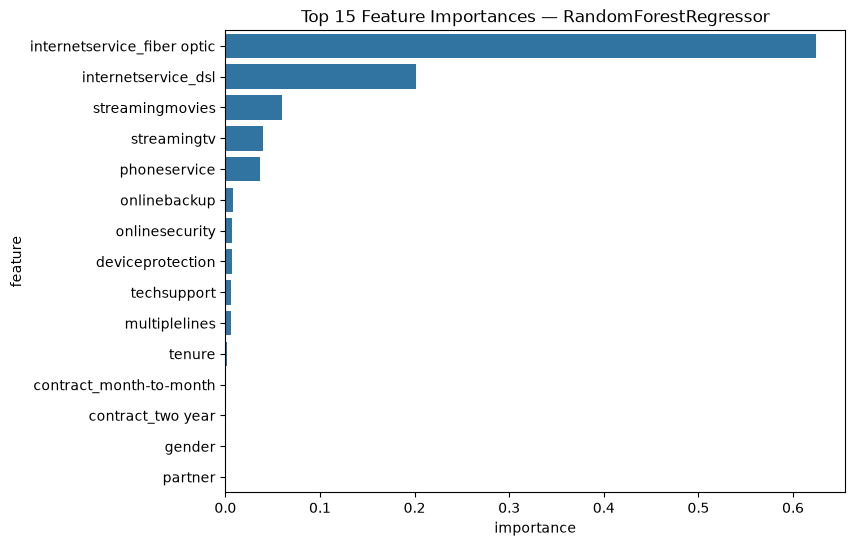

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importance.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances — RandomForestRegressor")
plt.show()

### Regresión Lineal: coeficientes

A diferencia del Random Forest, la Regresión Lineal es directamente interpretable a través de sus coeficientes: cada uno indica cuánto cambia el cargo mensual estimado por cada unidad de cambio en esa variable (manteniendo las demás constantes). El **signo** indica la dirección de la relación (positiva o negativa) y la **magnitud**, qué tanto pesa esa variable — con la salvedad de que, al no estar las variables en la misma escala, la magnitud no es directamente comparable entre variables numéricas y variables binarias (dummies).

In [18]:
coeficientes = pd.DataFrame({
    "feature": X_train.columns,
    "coeficiente": models["LinearRegression"].coef_
}).sort_values("coeficiente", ascending=False)

coeficientes

,feature,coeficiente
15,internetservice_fiber optic,50.018614
14,internetservice_dsl,25.037993
5,phoneservice,20.043032
11,streamingtv,9.984494
12,streamingmovies,9.957786
10,techsupport,5.055538
9,deviceprotection,5.046432
6,multiplelines,5.036223
7,onlinesecurity,5.017255
8,onlinebackup,4.965236


## Prueba con un cliente nuevo

Como en los módulos anteriores, se simula el uso del modelo con un solo registro: se toma un cliente del conjunto de `test`, se le asigna un identificador ficticio, y se compara el cargo mensual estimado por el modelo contra el cargo real registrado.

In [19]:
new_customer = X_test.iloc[[0]].reset_index(drop=True).rename({0: "ABC-DEF"})
new_customer.T

,ABC-DEF
gender,1
seniorcitizen,0
partner,0
dependents,1
tenure,13
phoneservice,0
multiplelines,0
onlinesecurity,0
onlinebackup,1
deviceprotection,0


In [20]:
cargo_estimado = models[best_model_name].predict(new_customer)[0]
cargo_real = y_test.iloc[0]

print(f"Cargo mensual estimado para 'ABC-DEF' ({best_model_name}): {cargo_estimado:,.2f}")
print(f"Cargo mensual real registrado: {cargo_real:,.2f}")
print(f"Diferencia: {(cargo_estimado - cargo_real):,.2f}")

Cargo mensual estimado para 'ABC-DEF' (LinearRegression): 29.93
Cargo mensual real registrado: 30.15
Diferencia: -0.22


## Guardar el modelo

Se persisten los artefactos del experimento de regresión, siguiendo el mismo patrón usado en `4_Modeling.ipynb`. Se usan nombres de archivo distintos (prefijo `regression_` y sufijo `_regression`) para no sobrescribir los artefactos del modelo de **clasificación** que ya están guardados en `../models/` — ambos modelos conviven en la misma carpeta pero resuelven problemas distintos.

In [21]:
import joblib

joblib.dump({
    "X_train": X_train, "y_train": y_train,
    "X_test": X_test, "y_test": y_test
}, "../models/regression_data.pkl")

joblib.dump(models, "../models/regression_modelos_entrenados.pkl")

joblib.dump({
    "train_metrics": train_metrics,
    "test_metrics": test_metrics,
    "cv_scores": cv_scores
}, "../models/regression_metrics.pkl")

joblib.dump(models[best_model_name], f"../models/{best_model_name}_regression.pkl")

print("Modelo, datos y métricas de regresión guardados en ../models/")

Modelo, datos y métricas de regresión guardados en ../models/
